In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

This notebook serves as a preliminary exploration of the TB data. 

In [3]:
tb_df = pd.read_csv('../data/real/processed/tb_pheno_geno_clean.csv')

tb_df.columns = tb_df.columns.str.strip()
outcome_cols = ['interp_bdq12', 'interp_bdq25', 
                'interp_dlm016', 'interp_dlm06', 
                'interp_lnz1']
for col in outcome_cols:
    tb_df[col] = tb_df[col].astype('Int64')

tb_df.head()


,isolate,glims,type,lineage,prop_mutants_bdq12,interp_bdq12,prop_mutants_bdq25,interp_bdq25,prop_mutants_dlm016,interp_dlm016,...,fbid_Val211Gly,fgd1_G*357C,fgd1_Gly120Gly,fgd1_Leu142Leu,fgd1_Lys270Met,fgd1_Phe320Phe,fgd1_T-27G,ddn_C-85A,ddn_Pro124Pro,ddn_Trp88STOP
0,1,2202059251,0,4,0.001,0,0.001,0,0.010,0,...,0,0,0,0,0,0,0,0,0,0
1,2,2201006682,0,2,0.001,0,0.001,0,0.001,0,...,0,1,0,0,0,1,0,0,0,0
2,3,2201035703,0,4,0.001,0,0.001,0,0.010,0,...,0,0,0,0,0,0,0,0,0,0
3,4,2201073436,0,4,0.001,0,0.001,0,0.010,0,...,0,0,0,0,1,0,0,0,0,0
4,5,2112064683,0,2,0.001,0,0.001,0,NaN,<NA>,...,0,0,0,0,0,1,0,0,0,0


In [4]:
print(f"Shape: {tb_df.shape}")
print(f"\nColumn types:\n{tb_df.dtypes.value_counts()}")

Shape: (164, 212)

Column types:
int64      196
float64     10
Int64        5
str          1
Name: count, dtype: int64


In [5]:
metadata_cols = ['glims', 'isolate']
feature_cols = [c for c in tb_df.columns if c not in metadata_cols]

In [6]:
#missing values
missing = tb_df.isnull().sum()
print(f"Missing values:\n{missing[missing > 0].sort_values(ascending=False)}")

Missing values:
prop_mutants_dlm016    12
interp_dlm016          12
prop_mutants_dlm06      9
interp_dlm06            9
lnz_mic                 1
dtype: int64


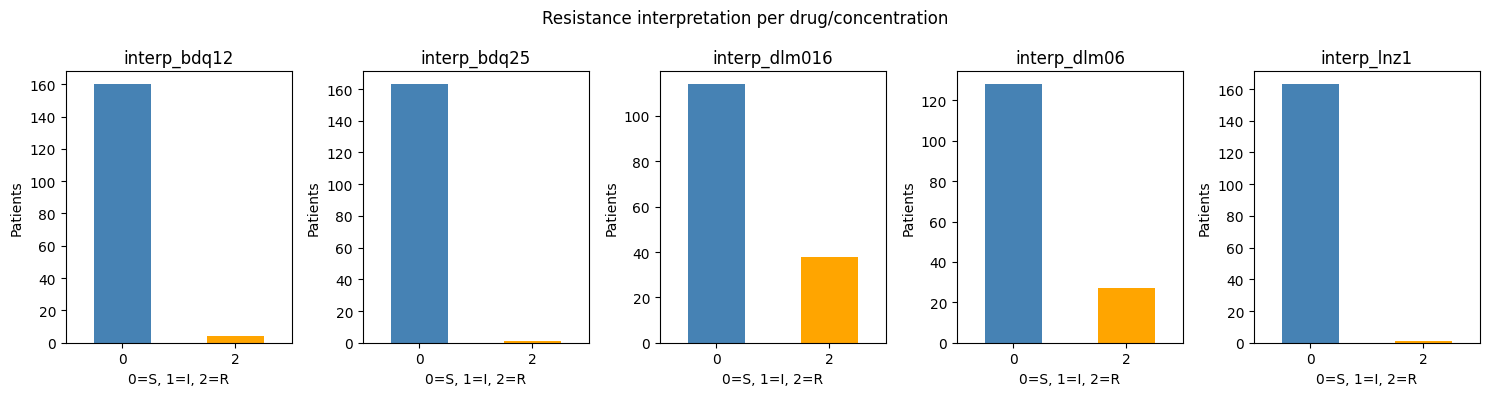

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for ax, col in zip(axes, outcome_cols):
    tb_df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color=['steelblue', 'orange', 'red'])
    ax.set_title(col)
    ax.set_xlabel('0=S, 1=I, 2=R')
    ax.set_ylabel('Patients')
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Resistance interpretation per drug/concentration')
plt.tight_layout()
plt.show()

In [8]:
#MIC distributions
print(tb_df[['bdq_mic', 'cfz_mic', 'lnz_mic', 'dlm_mic', 'ptm_mic']].describe())

          bdq_mic     cfz_mic     lnz_mic     dlm_mic     ptm_mic
count  164.000000  164.000000  163.000000  164.000000  164.000000
mean     0.535671    0.310244    0.585890    0.025927    0.317195
std      0.404733    0.306992    0.206717    0.042545    0.336856
min      0.120000    0.060000    0.250000    0.004000    0.030000
25%      0.250000    0.250000    0.500000    0.008000    0.120000
50%      0.500000    0.250000    0.500000    0.016000    0.250000
75%      0.500000    0.250000    0.500000    0.030000    0.250000
max      2.000000    2.000000    1.000000    0.250000    2.000000


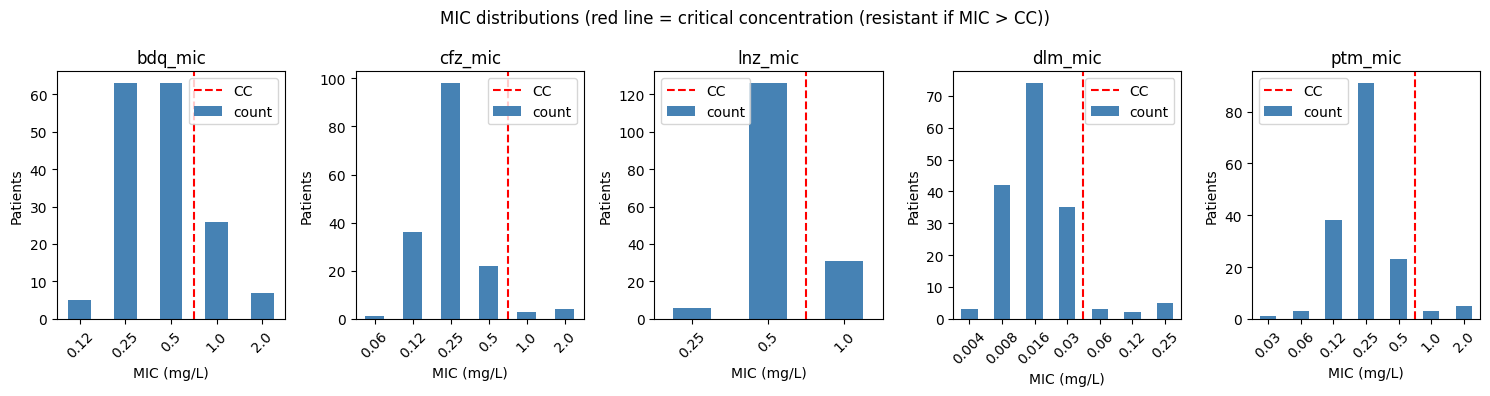

In [14]:
cc = {'bdq_mic': 1, 'cfz_mic': 1, 'lnz_mic': 1, 'dlm_mic': 0.06, 'ptm_mic': 1}

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for ax, col in zip(axes, ['bdq_mic', 'cfz_mic', 'lnz_mic', 'dlm_mic', 'ptm_mic']):
    counts = tb_df[col].dropna().value_counts().sort_index()
    counts.plot(kind='bar', ax=ax, color='steelblue')
    # add CC line
    labels = [float(t.get_text()) for t in ax.get_xticklabels()]
    if cc[col] in labels:
        idx = labels.index(cc[col])
        ax.axvline(x=idx - 0.5, color='red', linestyle='--', label='CC')
    ax.set_title(col)
    ax.set_ylabel('Patients')
    ax.set_xlabel('MIC (mg/L)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle('MIC distributions (red line = critical concentration (resistant if MIC > CC))')
plt.tight_layout()
plt.show()

In [ ]:
#Mutation sparsity
mut_cols = [c for c in tb_df.columns if c.startswith(('rv', 'mmpl', 'mmps', 'atpe', 'pepq', 'rplc', 'rrl', 'fbia', 'fbib', 'fbic', 'fbid', 'fgd1', 'ddn'))]
print(f"Mutation columns: {len(mut_cols)}")
prevalence = tb_df[mut_cols].mean() * 100
print(f"\nPrevalence stats:\n{prevalence.describe()}")
print(f"\nMutations in <5 patients: {(tb_df[mut_cols].sum() < 5).sum()}")
print(f"Mutations in 0 patients: {(tb_df[mut_cols].sum() == 0).sum()}")

Mutation columns: 193

Prevalence stats:
count    193.000000
mean       3.412107
std       11.870560
min        0.609756
25%        0.609756
50%        0.609756
75%        1.219512
max       98.780488
dtype: float64

Mutations in <5 patients: 170
Mutations in 0 patients: 0


In [17]:
mutation_cols = tb_df.loc[:, 'rv0678_Arg140_Tyr145dup':].columns
prevalent = (tb_df[mutation_cols].mean() * 100)
print(prevalent[prevalent >= 5].sort_values(ascending=False))

rv1979c_A-129G     98.780488
mmpl5_Ile948Val    98.170732
pepq_Ala87Gly      54.268293
mmpl5_Thr794Ile    39.024390
fgd1_Phe320Phe     39.024390
mmpl5_Asp767Asn    31.097561
fgd1_G*357C        29.878049
rv0678_G*128C      27.439024
rv1979c_C*135G     21.341463
fgd1_Lys270Met     14.634146
fbid_Thr207Pro     11.585366
fbic_Thr560Thr      8.536585
pepq_Leu163Arg      7.926829
fbic_C*92G          7.926829
fbid_T-298C         5.487805
rrl_1476188_C>T     5.487805
dtype: float64


In [ ]:
print(tb_df[['rv1979c_A-129G', 'mmpl5_Ile948Val']].value_counts()) #near-universal mutations

rv1979c_A-129G  mmpl5_Ile948Val
1               1                  161
0               0                    2
1               0                    1
Name: count, dtype: int64


In [16]:
#Lineage and resistance type
print(tb_df['lineage'].value_counts())
print()
print(tb_df['type'].value_counts())

lineage
4    100
2     57
3      4
1      3
Name: count, dtype: int64

type
0    134
1     23
2      7
Name: count, dtype: int64
